In [40]:
# Bisection Method Solver
# Author: Owen Purnomo
# Date: 07/01/2026
# We are solving 𝑓(𝑥)=0 on the interval[𝑎,𝑏],and 𝑓(𝑎)*𝑓(𝑏)<0.
# The desired level oferror (in finding the zero of the function) is 𝜖 (Elipson)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

In [42]:

def make_function(expr_str):
    x = sp.symbols('x')
    expr = sp.sympify(expr_str)         
    f = sp.lambdify(x, expr, modules=['numpy'])
    return f, expr

In [43]:
#Bisection algorithm 
def bisection(f, a, b, eps, max_iter=200):
    if f(a) * f(b) >= 0:
        raise ValueError(f"f(a)*f(b) must be < 0. Got f({a})={f(a):.4g}, f({b})={f(b):.4g}")

    a_k, b_k = a, b
    records = []
    k = 1

    while k <= max_iter:
        c_k = (a_k + b_k) / 2
        records.append({
            "k": k, "a_k": a_k, "b_k": b_k, "c_k": c_k,
            "f(a_k)": f(a_k), "f(b_k)": f(b_k), "f(c_k)": f(c_k),
            "b_k - c_k": b_k - c_k
        })
        if b_k - c_k < eps:
            x_star = c_k
            return x_star, pd.DataFrame(records)

        if f(b_k) * f(c_k) < 0:
            a_k, b_k = c_k, b_k
        else:
            a_k, b_k = a_k, c_k

        k += 1

    raise RuntimeError("Max iterations reached without convergence")


In [46]:
def solve_bisection(expr_str, a, b, eps=1e-6, show_table=True, show_plot=True):
    """
    Example:
        solve_bisection("x**3 - x - 2", a=1, b=2, eps=1e-6)
        solve_bisection("cos(x) - x", a=0, b=1, eps=1e-8)
        solve_bisection("exp(-x) - x", a=0, b=1)
    """
    f, expr = make_function(expr_str)
    x_star, history = bisection(f, a, b, eps)

    print(f"f(x) = {expr}")
    print(f"Interval: [{a}, {b}],  epsilon = {eps}")
    print(f"Approximate root: x* = {x_star:.8f}")
    print(f"f(x*) = {f(x_star):.2e}")
    print(f"Iterations used: {len(history)}")

    if show_table:
        display(history)

    if show_plot:
        plot_bisection(f, expr, history, a, b, x_star)

    return x_star, history

In [47]:
def plot_bisection(f, expr, history, a, b, x_star, n_points=400):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x_vals = np.linspace(a, b, n_points)
    y_vals = f(x_vals)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].plot(x_vals, y_vals, label=f"f(x) = {sp.pretty(expr, use_unicode=False)}", color="steelblue")
    axes[0].scatter(history["c_k"], [f(c) for c in history["c_k"]],
                     color="crimson", zorder=5, s=25, label="$c_k$ iterates")
    for _, row in history.iterrows():
        axes[0].annotate(str(int(row["k"])), (row["c_k"], f(row["c_k"])),
                          textcoords="offset points", xytext=(0, 8), fontsize=8, color="crimson")
    axes[0].scatter([x_star], [f(x_star)], color="green", zorder=6, s=60,
                     marker="*", label=f"root ≈ {x_star:.6f}")
    axes[0].set_title("Bisection iterates on f(x)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("f(x)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history["k"], history["b_k"] - history["a_k"], marker="o", color="darkorange")
    axes[1].set_yscale("log")
    axes[1].set_title("Interval width $b_k - a_k$ vs Iteration")
    axes[1].set_xlabel("Iteration k")
    axes[1].set_ylabel("$b_k - a_k$ (log scale)")
    axes[1].grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

f(x) = -x + cos(x)
Interval: [0, 1],  epsilon = 1e-08
Approximate root: x* = 0.73908513
f(x*) = 4.72e-09
Iterations used: 27


,k,a_k,b_k,c_k,f(a_k),f(b_k),f(c_k),b_k - c_k
0,1,0.000000,1.000000,0.500000,1.000000e+00,-4.596977e-01,3.775826e-01,5.000000e-01
1,2,0.500000,1.000000,0.750000,3.775826e-01,-4.596977e-01,-1.831113e-02,2.500000e-01
2,3,0.500000,0.750000,0.625000,3.775826e-01,-1.831113e-02,1.859631e-01,1.250000e-01
3,4,0.625000,0.750000,0.687500,1.859631e-01,-1.831113e-02,8.533495e-02,6.250000e-02
4,5,0.687500,0.750000,0.718750,8.533495e-02,-1.831113e-02,3.387937e-02,3.125000e-02
5,6,0.718750,0.750000,0.734375,3.387937e-02,-1.831113e-02,7.874725e-03,1.562500e-02
6,7,0.734375,0.750000,0.742188,7.874725e-03,-1.831113e-02,-5.195712e-03,7.812500e-03
7,8,0.734375,0.742188,0.738281,7.874725e-03,-5.195712e-03,1.345150e-03,3.906250e-03
8,9,0.738281,0.742188,0.740234,1.345150e-03,-5.195712e-03,-1.923873e-03,1.953125e-03
9,10,0.738281,0.740234,0.739258,1.345150e-03,-1.923873e-03,-2.890091e-04,9.765625e-04


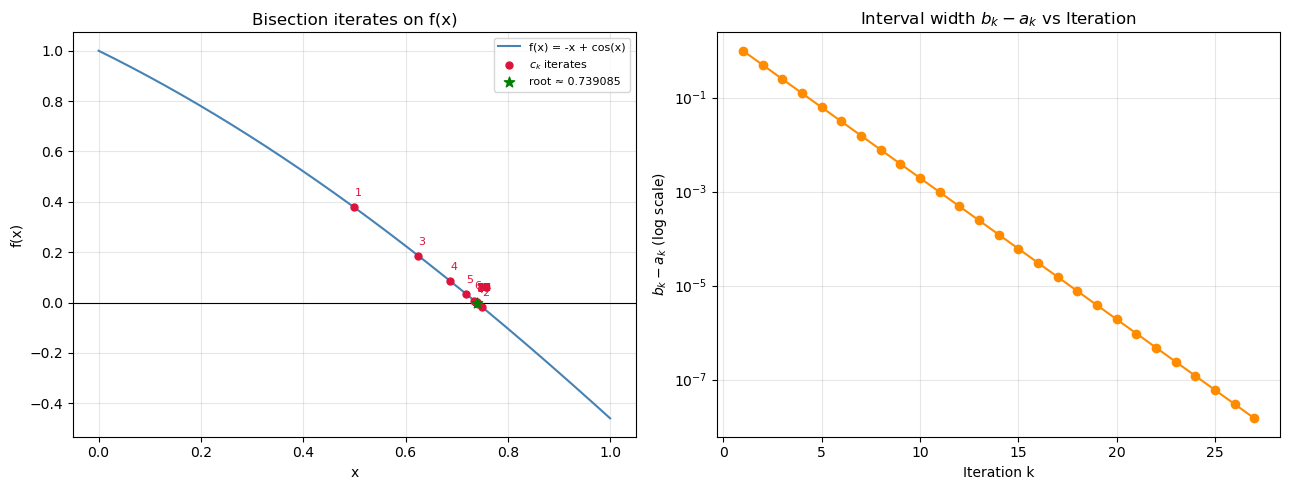

(0.7390851303935051,
      k       a_k       b_k       c_k        f(a_k)        f(b_k)  \
 0    1  0.000000  1.000000  0.500000  1.000000e+00 -4.596977e-01   
 1    2  0.500000  1.000000  0.750000  3.775826e-01 -4.596977e-01   
 2    3  0.500000  0.750000  0.625000  3.775826e-01 -1.831113e-02   
 3    4  0.625000  0.750000  0.687500  1.859631e-01 -1.831113e-02   
 4    5  0.687500  0.750000  0.718750  8.533495e-02 -1.831113e-02   
 5    6  0.718750  0.750000  0.734375  3.387937e-02 -1.831113e-02   
 6    7  0.734375  0.750000  0.742188  7.874725e-03 -1.831113e-02   
 7    8  0.734375  0.742188  0.738281  7.874725e-03 -5.195712e-03   
 8    9  0.738281  0.742188  0.740234  1.345150e-03 -5.195712e-03   
 9   10  0.738281  0.740234  0.739258  1.345150e-03 -1.923873e-03   
 10  11  0.738281  0.739258  0.738770  1.345150e-03 -2.890091e-04   
 11  12  0.738770  0.739258  0.739014  5.281584e-04 -2.890091e-04   
 12  13  0.739014  0.739258  0.739136  1.195967e-04 -2.890091e-04   
 13  14  0.73

In [48]:
solve_bisection("cos(x) - x", a=0, b=1, eps=1e-8)

f(x) = -x + exp(-x)
Interval: [0, 1],  epsilon = 1e-06
Approximate root: x* = 0.56714344
f(x*) = -2.35e-07
Iterations used: 20


,k,a_k,b_k,c_k,f(a_k),f(b_k),f(c_k),b_k - c_k
0,1,0.000000,1.000000,0.500000,1.000000,-0.632121,1.065307e-01,5.000000e-01
1,2,0.500000,1.000000,0.750000,0.106531,-0.632121,-2.776334e-01,2.500000e-01
2,3,0.500000,0.750000,0.625000,0.106531,-0.277633,-8.973857e-02,1.250000e-01
3,4,0.500000,0.625000,0.562500,0.106531,-0.089739,7.282825e-03,6.250000e-02
4,5,0.562500,0.625000,0.593750,0.007283,-0.089739,-4.149755e-02,3.125000e-02
5,6,0.562500,0.593750,0.578125,0.007283,-0.041498,-1.717584e-02,1.562500e-02
6,7,0.562500,0.578125,0.570312,0.007283,-0.017176,-4.963760e-03,7.812500e-03
7,8,0.562500,0.570312,0.566406,0.007283,-0.004964,1.155202e-03,3.906250e-03
8,9,0.566406,0.570312,0.568359,0.001155,-0.004964,-1.905360e-03,1.953125e-03
9,10,0.566406,0.568359,0.567383,0.001155,-0.001905,-3.753492e-04,9.765625e-04


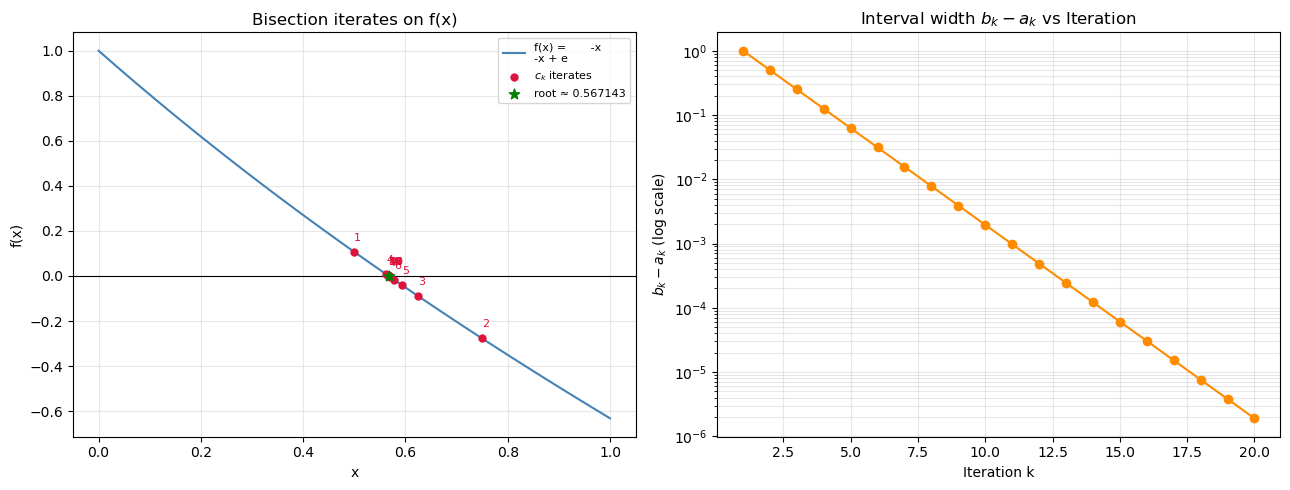

(0.567143440246582,
      k       a_k       b_k       c_k    f(a_k)    f(b_k)        f(c_k)  \
 0    1  0.000000  1.000000  0.500000  1.000000 -0.632121  1.065307e-01   
 1    2  0.500000  1.000000  0.750000  0.106531 -0.632121 -2.776334e-01   
 2    3  0.500000  0.750000  0.625000  0.106531 -0.277633 -8.973857e-02   
 3    4  0.500000  0.625000  0.562500  0.106531 -0.089739  7.282825e-03   
 4    5  0.562500  0.625000  0.593750  0.007283 -0.089739 -4.149755e-02   
 5    6  0.562500  0.593750  0.578125  0.007283 -0.041498 -1.717584e-02   
 6    7  0.562500  0.578125  0.570312  0.007283 -0.017176 -4.963760e-03   
 7    8  0.562500  0.570312  0.566406  0.007283 -0.004964  1.155202e-03   
 8    9  0.566406  0.570312  0.568359  0.001155 -0.004964 -1.905360e-03   
 9   10  0.566406  0.568359  0.567383  0.001155 -0.001905 -3.753492e-04   
 10  11  0.566406  0.567383  0.566895  0.001155 -0.000375  3.898588e-04   
 11  12  0.566895  0.567383  0.567139  0.000390 -0.000375  7.237912e-06   
 12  

In [49]:
solve_bisection("exp(-x) - x", a=0, b=1)